# Topological features for PyTorch classifiers

This tutorial shows how to turn point cloud data into fixed-size topological feature vectors using masspcf, and feed them into a PyTorch neural network for classification.

The pipeline looks like this:

```
Point clouds  -->  Persistent homology  -->  Functional summaries (PCFs)
                                                     |
                                                Evaluate on grid
                                                     |
                                                NumPy feature vectors
                                                     |
                                                torch.from_numpy()
                                                     |
                                                PyTorch model
```

The key insight is that functional summaries (stable ranks, Betti curves, APFs) are piecewise constant functions, and evaluating them on a fixed grid of time points produces ordinary numeric vectors that any neural network can consume.

## Step 1: Generate data

We create two classes of point clouds with different topological structure:
- **Class 0**: points sampled uniformly from a filled disk (no persistent loop)
- **Class 1**: points sampled from an annulus (one persistent H1 loop)

In [1]:
import numpy as np
import masspcf as mpcf
from masspcf import persistence as mpers

rng = np.random.default_rng(42)
n_samples = 200
n_points = 60

def sample_disk(n, rng):
    """Uniform samples from a filled unit disk."""
    r = np.sqrt(rng.uniform(0, 1, n))
    theta = rng.uniform(0, 2 * np.pi, n)
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)]).astype(np.float32)

def sample_annulus(n, rng):
    """Uniform samples from an annulus (r in [0.8, 1.2])."""
    r = np.sqrt(rng.uniform(0.8**2, 1.2**2, n))
    theta = rng.uniform(0, 2 * np.pi, n)
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)]).astype(np.float32)

pclouds = mpcf.zeros((n_samples,), dtype=mpcf.pcloud32)
labels = np.zeros(n_samples, dtype=np.int64)

for i in range(n_samples):
    if i < n_samples // 2:
        pclouds[i] = sample_disk(n_points, rng)
        labels[i] = 0
    else:
        pclouds[i] = sample_annulus(n_points, rng)
        labels[i] = 1

print(f"Point clouds: {pclouds.shape}, Labels: {labels.shape}")

Point clouds: Shape(200), Labels: (200,)


Let's visualize one example from each class:

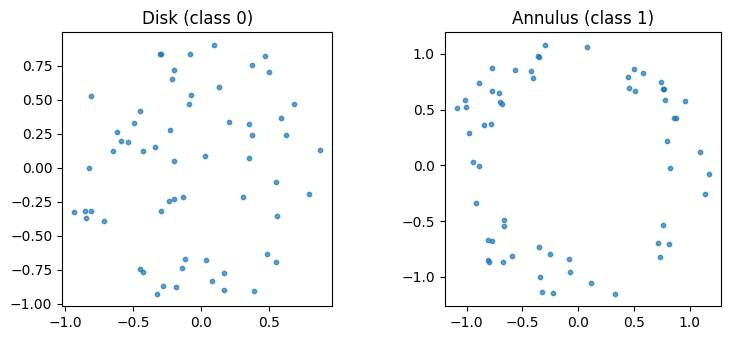

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, idx, title in zip(axes, [0, n_samples // 2], ["Disk (class 0)", "Annulus (class 1)"]):
    pts = pclouds[idx].to_numpy() if hasattr(pclouds[idx], 'to_numpy') else np.array(pclouds[idx])
    ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.7)
    ax.set_aspect("equal")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 2: Compute topological features

We compute persistent homology up to dimension 1, convert the barcodes to stable rank PCFs, and then evaluate them on a fixed grid to get feature vectors.

In [3]:
# Persistent homology (H0 and H1)
barcodes = mpers.compute_persistent_homology(pclouds, max_dim=1)
print(f"Barcodes shape: {barcodes.shape}")  # (200, 2)

# Convert to stable rank PCFs
sranks = mpers.barcode_to_stable_rank(barcodes)
print(f"Stable ranks shape: {sranks.shape}")  # (200, 2)

Barcodes shape: Shape(200, 2)
Stable ranks shape: Shape(200, 2)


In [4]:
# Evaluate H1 stable ranks on a grid to get fixed-size feature vectors
grid = np.linspace(0, 2.0, 50, dtype=np.float32)
features = sranks[:, 1](grid)   # shape (200, 50)
print(f"Feature matrix shape: {features.shape}")

Feature matrix shape: (200, 50)


Let's visualize the H1 stable ranks for each class. The annulus class should show more persistent H1 features (loops).

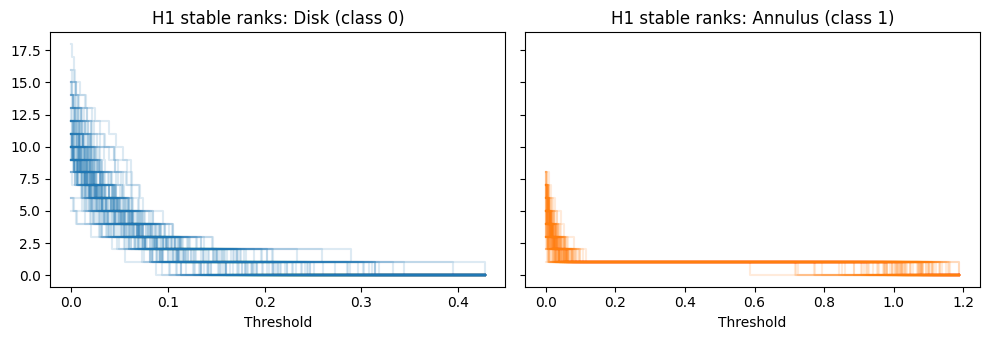

In [5]:
from masspcf.plotting import plot as plotpcf

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

half = n_samples // 2
plotpcf(sranks[:half, 1], ax=axes[0], alpha=0.15, color="C0")
axes[0].set_title("H1 stable ranks: Disk (class 0)")
axes[0].set_xlabel("Threshold")

plotpcf(sranks[half:, 1], ax=axes[1], alpha=0.15, color="C1")
axes[1].set_title("H1 stable ranks: Annulus (class 1)")
axes[1].set_xlabel("Threshold")

plt.tight_layout()
plt.show()

## Step 3: Train a PyTorch classifier

Now we convert the features to PyTorch tensors and train a simple feedforward network.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Convert to PyTorch tensors
X = torch.from_numpy(features)
y = torch.from_numpy(labels)

# Train/test split
n_train = 160
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32, shuffle=True
)

In [7]:
# A small feedforward network
model = nn.Sequential(
    nn.Linear(50, 32),
    nn.ReLU(),
    nn.Linear(32, 2),
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Training loop
for epoch in range(50):
    for X_batch, y_batch in train_loader:
        loss = loss_fn(model(X_batch), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            train_acc = (model(X_train).argmax(1) == y_train).float().mean()
            print(f"Epoch {epoch+1:3d}  loss={loss.item():.4f}  train_acc={train_acc:.0%}")

Epoch  10  loss=0.1324  train_acc=100%
Epoch  20  loss=0.0457  train_acc=100%
Epoch  30  loss=0.0155  train_acc=100%
Epoch  40  loss=0.0119  train_acc=100%
Epoch  50  loss=0.0102  train_acc=100%


In [8]:
# Evaluate on test set
with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean().item()
    print(f"Test accuracy: {acc:.0%}")

Test accuracy: 100%


Because the annulus has a prominent H1 feature (a persistent loop) that the filled disk lacks, the stable rank vectors for the two classes are quite distinct, and even a small network can learn to separate them.

## Variations

### Different summaries

Replace `barcode_to_stable_rank` with `barcode_to_betti_curve` or `barcode_to_accumulated_persistence` for alternative representations. You can also concatenate features from multiple summaries or homology dimensions.

### Kernel methods

Instead of vectorizing, use `mpcf.l2_kernel` to compute a kernel matrix directly from the PCFs, then convert to PyTorch. This is useful with kernel-based models or as a precomputed similarity matrix for contrastive learning.

In [9]:
K = mpcf.l2_kernel(sranks[:, 1]).to_dense()
K_torch = torch.from_numpy(K)
print(f"Kernel matrix shape: {K_torch.shape}")

Kernel matrix shape: torch.Size([200, 200])


### Distance matrices

Similarly, `mpcf.pdist` gives pairwise distances that can be used for metric learning or as input to distance-based classifiers.

In [10]:
D = mpcf.pdist(sranks[:, 1]).to_dense()
D_torch = torch.from_numpy(D)
print(f"Distance matrix shape: {D_torch.shape}")

Distance matrix shape: torch.Size([200, 200])
